Libraries to read and split data & measure accuracy

In [1]:
import numpy as np
import pandas as pd
import random

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score


Read the Dataset


In [4]:
data = pd.read_csv("mammographic.dat", comment='@', header=None)

data.columns = [
    "BI-RADS", "Age", "Shape", "Margin", "Density", "Severity"
]

data.head()

,BI-RADS,Age,Shape,Margin,Density,Severity
0,5,67,3,5,3,1
1,4,43,1,1,?,1
2,5,58,4,5,3,1
3,4,28,1,1,3,0
4,5,74,1,5,?,1


961 rows(mammogram record), 6 columns

In [5]:
data.shape


(961, 6)

Replace missing values(131 data)

In [6]:
data.replace("?", np.nan, inplace=True)
data = data.astype(float)
data.fillna(data.mean(), inplace=True)


Split input and output

In [7]:
X = data[["BI-RADS", "Age", "Shape", "Margin", "Density"]]
y = data["Severity"]


Normalize data

In [8]:
scaler = MinMaxScaler()
X = scaler.fit_transform(X)


Split dataset(70/30)

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)


1. Evolutionary ALgorithm(GA)

In [10]:
def fitness(chromosome):
    predictions = np.dot(X_train, chromosome)
    predictions = (predictions > 0.5).astype(int)
    return accuracy_score(y_train, predictions)


In [11]:
def create_population(size, n_features):
    return [np.random.rand(n_features) for _ in range(size)]


In [12]:
def select(population):
    return random.sample(population, 2)


In [13]:
def crossover(parent1, parent2):
    point = random.randint(1, len(parent1)-1)
    return np.concatenate((parent1[:point], parent2[point:]))


In [14]:
def mutate(chromosome, rate=0.1):
    for i in range(len(chromosome)):
        if random.random() < rate:
            chromosome[i] = random.random()
    return chromosome


In [111]:
population = create_population(20, X_train.shape[1])

for generation in range(50):
    new_population = []
    for _ in range(20):
        p1, p2 = select(population)
        child = crossover(p1, p2)
        child = mutate(child)
        new_population.append(child)
    population = new_population


Testing Evolutionary Algorithm

In [112]:
best = max(population, key=fitness)

predictions = np.dot(X_test, best)
predictions = (predictions > 0.5).astype(int)

ga_results = {
    "Accuracy": accuracy_score(y_test, predictions),
    "Precision": precision_score(y_test, predictions),
    "Recall": recall_score(y_test, predictions),
    "F1": f1_score(y_test, predictions)
}

ga_results


{'Accuracy': 0.5294117647058824,
 'Precision': 0.4924812030075188,
 'Recall': 0.9924242424242424,
 'F1': 0.6582914572864321}

Confusion Matrix

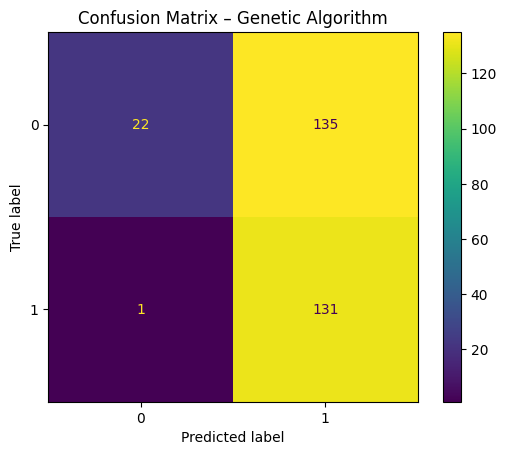

In [113]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

cm_ga = confusion_matrix(y_test, predictions)
ConfusionMatrixDisplay(cm_ga).plot()
plt.title("Confusion Matrix – Genetic Algorithm")
plt.show()


2. Hybrid Algorithm(GA + Fuzzy)

In [17]:
!pip install scikit-fuzzy


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 920.8/920.8 kB 13.6 MB/s eta 0:00:00


In [18]:
import skfuzzy as fuzz


In [19]:
def fuzzy_fitness(params):
    threshold = params[0]
    preds = (X_train[:, 0] > threshold).astype(int)
    return accuracy_score(y_train, preds)


In [102]:
population = [np.random.rand(1) for _ in range(20)]

for gen in range(40):
    new_pop = []
    for _ in range(20):
        p1, p2 = random.sample(population, 2)
        child = p1.copy()          # no crossover
        child = mutate(child, 0.2)
        new_pop.append(child)
    population = new_pop


Testing Hybrid algorithm

In [103]:
best_param = max(population, key=fuzzy_fitness)

hybrid_preds = (X_test[:, 0] > best_param[0]).astype(int)

hybrid_results = {
    "Accuracy": accuracy_score(y_test, hybrid_preds),
    "Precision": precision_score(y_test, hybrid_preds),
    "Recall": recall_score(y_test, hybrid_preds),
    "F1": f1_score(y_test, hybrid_preds)
}

hybrid_results


{'Accuracy': 0.8200692041522492,
 'Precision': 0.8571428571428571,
 'Recall': 0.7272727272727273,
 'F1': 0.7868852459016393}

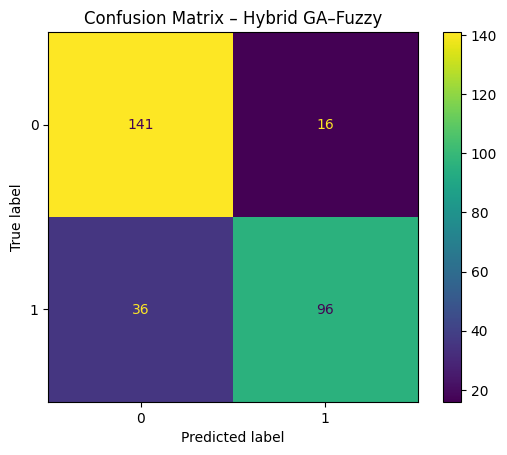

In [106]:
cm_hybrid = confusion_matrix(y_test, hybrid_preds)
ConfusionMatrixDisplay(cm_hybrid).plot()
plt.title("Confusion Matrix – Hybrid GA–Fuzzy")
plt.show()


Comparison Graph

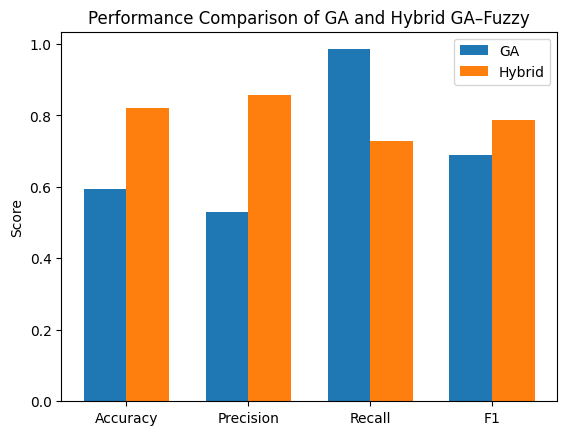

In [104]:
import matplotlib.pyplot as plt
import numpy as np

metrics = ["Accuracy", "Precision", "Recall", "F1"]
ga_values = [ga_results[m] for m in metrics]
hybrid_values = [hybrid_results[m] for m in metrics]

x = np.arange(len(metrics))
width = 0.35

plt.figure()
plt.bar(x - width/2, ga_values, width, label='GA')
plt.bar(x + width/2, hybrid_values, width, label='Hybrid')

plt.xticks(x, metrics)
plt.ylabel("Score")
plt.title("Performance Comparison of GA and Hybrid GA–Fuzzy")
plt.legend()
plt.show()
